In [3]:

import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("dataset_spotify.csv")
df.columns




Index(['track_id', 'track_name', 'artist_name', 'album_name', 'release_date',
       'genre', 'duration_ms', 'popularity', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count',
       'country', 'explicit', 'label', 'release_year', 'release_month',
       'release_day_of_week', 'duration_minutes', 'popularity_category',
       'loudness_category', 'key_name', 'mode_name', 'is_explicit_bool',
       'release_quarter', 'is_weekend_release', 'log_stream_count',
       'upbeat_score', 'artist_track_count'],
      dtype='str')

In [4]:
# PASO 1: identificar qué géneros tienen 2000 o más canciones
conteo_generos = df['genre'].value_counts()
generos_grandes = conteo_generos[conteo_generos >= 2000].index.tolist()

# PASO 2: crear la nueva columna 'genre_group'
# si el género está en la lista de "grandes", se queda igual; si no, se pone "Otros"
df['genre_group'] = df['genre'].apply(lambda g: g if g in generos_grandes else 'Otros')

# PASO 3: agrupar por genre_group Y release_year, y contar canciones (usando track_id)
tabla = df.groupby(['genre_group', 'release_year'])['track_id'].count().unstack(level=1)

print(tabla)

release_year  2020  2021  2022  2023  2024  2025
genre_group                                     
EDM            428   398   372   384   418   407
Folk           377   377   358   405   363   369
Hip-Hop        641   676   637   644   673   659
Latin          422   443   425   426   470   475
Otros         1697  1702  1730  1664  1724  1678
Pop           2150  2166  2122  2139  2216  2122
R&B           2225  2245  2217  2180  2160  2246
Rock           415   380   396   400   417   362


<Axes: title={'center': 'Canciones por género y año'}, xlabel='genre_group'>

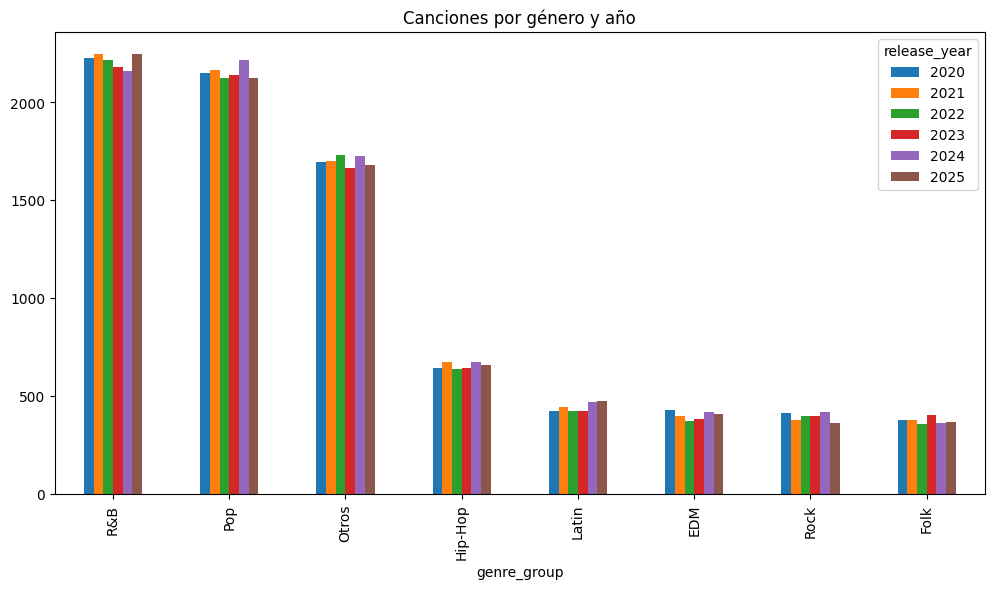

In [5]:
orden = tabla.sum(axis=1).sort_values(ascending=False).index.tolist()
tabla_ordenada=tabla.reindex(orden)
tabla_ordenada.plot(kind='bar', figsize=(12,6), title="Canciones por género y año")

